In [1]:
import pandas as pd
import numpy as  np



In [2]:
df = pd.read_csv('../data/cleaned_data.csv')
df.head()

,specialty,appointment_time,gender,no_show,disability,place,appointment_shift,age,under_12_years_old,over_60_years_old,...,storm_day_before,rain_intensity,heat_intensity,appointment_date_continuous,Hipertension,Diabetes,Alcoholism,Handcap,Scholarship,SMS_received
0,psychotherapy,1970-01-01 00:00:00.000000017,F,yes,intellectual,Lake Marvinville,afternoon,9.0,1,0,...,1,no_rain,warm,01-01-2020,0,0,0,0,0,0
1,psychotherapy,1970-01-01 00:00:00.000000007,M,no,intellectual,ITAPEMA,morning,11.0,1,0,...,1,no_rain,cold,01-01-2020,0,0,0,0,0,0
2,speech therapy,1970-01-01 00:00:00.000000016,M,no,intellectual,ITAJAÍ,afternoon,8.0,1,0,...,1,no_rain,warm,01-01-2020,0,0,0,0,0,0
3,speech therapy,1970-01-01 00:00:00.000000014,M,yes,intellectual,Sarahside,afternoon,9.0,1,0,...,1,moderate,mild,01-01-2020,0,0,0,0,0,1
4,physiotherapy,1970-01-01 00:00:00.000000008,M,no,motor,ITAJAÍ,morning,12.0,0,0,...,1,no_rain,mild,01-01-2020,0,0,0,0,0,0


In [4]:
df.columns

Index(['specialty', 'appointment_time', 'gender', 'no_show', 'disability',
       'place', 'appointment_shift', 'age', 'under_12_years_old',
       'over_60_years_old', 'patient_needs_companion', 'average_temp_day',
       'average_rain_day', 'max_temp_day', 'max_rain_day', 'rainy_day_before',
       'storm_day_before', 'rain_intensity', 'heat_intensity',
       'appointment_date_continuous', 'Hipertension', 'Diabetes', 'Alcoholism',
       'Handcap', 'Scholarship', 'SMS_received'],
      dtype='object')

In [5]:
num_cols = df.select_dtypes(
    include=['int64', 'float64']
).columns

print("Numerical Columns:")
print(num_cols)

Numerical Columns:
Index(['age', 'under_12_years_old', 'over_60_years_old',
       'patient_needs_companion', 'average_temp_day', 'average_rain_day',
       'max_temp_day', 'max_rain_day', 'rainy_day_before', 'storm_day_before',
       'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'Scholarship',
       'SMS_received'],
      dtype='object')


In [6]:
num_cols = [
    'age',
    'average_temp_day',
    'average_rain_day',
    'max_temp_day',
    'max_rain_day'
]

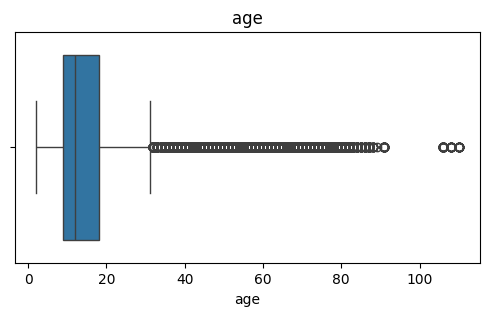

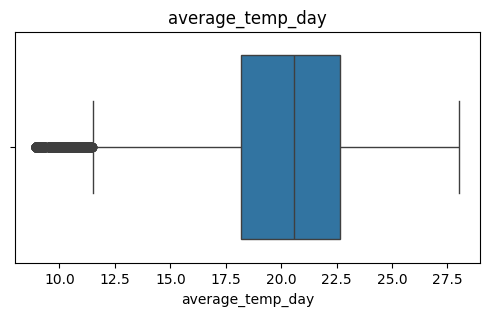

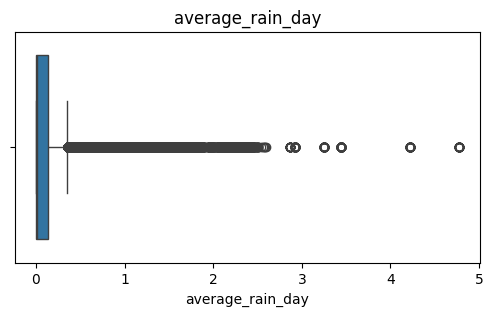

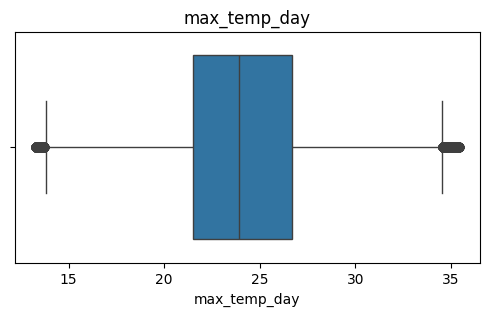

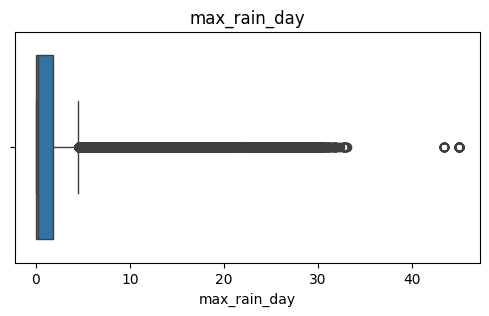

In [7]:
#Chaeck the outliers
import seaborn as sns
import matplotlib.pyplot as plt

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [8]:
for col in num_cols:
    print("\n", col)
    print(df[col].describe())
    print("Outliers count (>99%):", (df[col] > df[col].quantile(0.99)).sum())
    print("Outliers count (<1%):", (df[col] < df[col].quantile(0.01)).sum())


 age
count    109304.000000
mean         17.257164
std          15.953587
min           2.000000
25%           9.000000
50%          12.000000
75%          18.000000
max         110.000000
Name: age, dtype: float64
Outliers count (>99%): 966
Outliers count (<1%): 245

 average_temp_day
count    109304.000000
mean         20.358134
std           3.410171
min           8.940000
25%          18.190000
50%          20.600000
75%          22.660000
max          28.010000
Name: average_temp_day, dtype: float64
Outliers count (>99%): 1093
Outliers count (<1%): 1056

 average_rain_day
count    109304.000000
mean          0.179260
std           0.412541
min           0.000000
25%           0.000000
50%           0.010000
75%           0.140000
max           4.770000
Name: average_rain_day, dtype: float64
Outliers count (>99%): 1068
Outliers count (<1%): 0

 max_temp_day
count    109304.000000
mean         24.042553
std           3.911417
min          13.300000
25%          21.500000
50%       

In [9]:

#Donot REMOVE, CAP (Winsorization)
for col in num_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)

    df[col] = df[col].clip(lower, upper)

In [10]:
df[num_cols].describe()

,age,average_temp_day,average_rain_day,max_temp_day,max_rain_day
count,109304.000000,109304.000000,109304.000000,109304.000000,109304.000000
mean,17.198712,20.368331,0.175429,24.042099,1.938679
std,15.690498,3.367268,0.386507,3.881697,3.909354
min,4.000000,11.610000,0.000000,14.800000,0.000000
25%,9.000000,18.190000,0.000000,21.500000,0.000000
50%,12.000000,20.600000,0.010000,23.900000,0.200000
75%,18.000000,22.660000,0.140000,26.700000,1.800000
max,77.000000,26.770000,2.230000,33.700000,21.300000


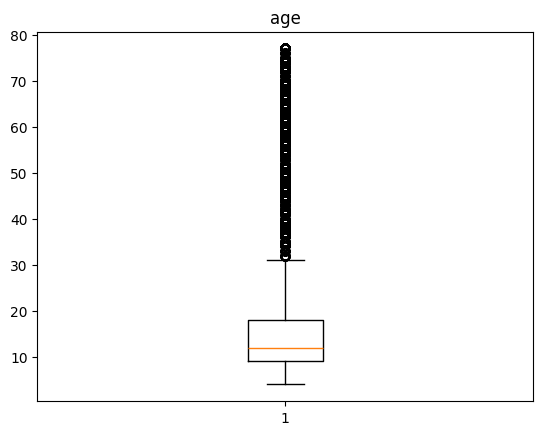

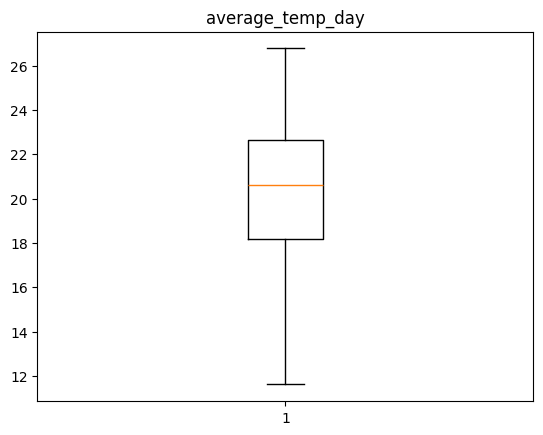

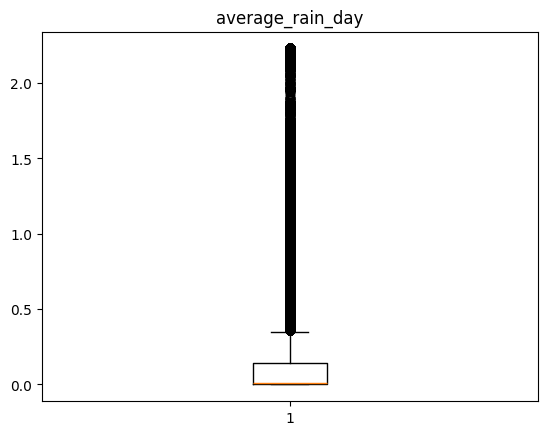

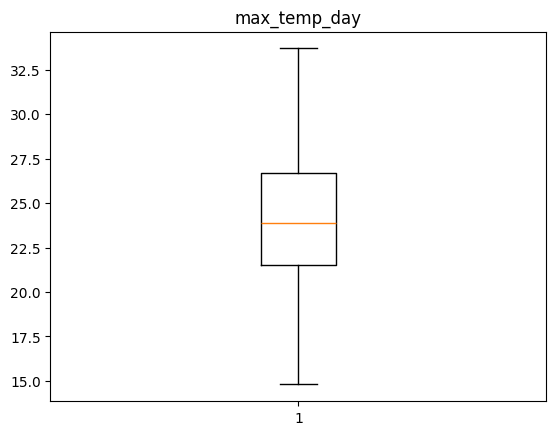

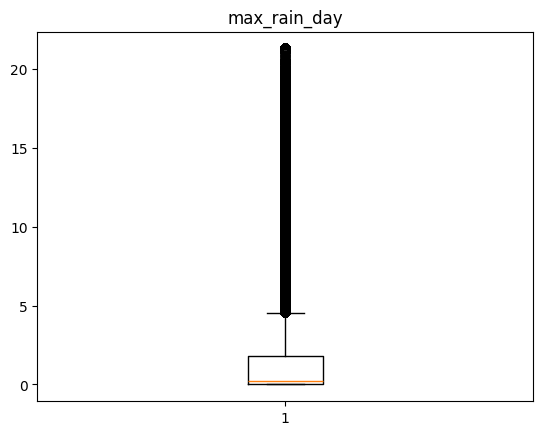

In [11]:
#After cap the Outliers
import matplotlib.pyplot as plt

for col in num_cols:
    plt.boxplot(df[col])
    plt.title(col)
    plt.show()

In [13]:
df.columns

Index(['specialty', 'appointment_time', 'gender', 'no_show', 'disability',
       'place', 'appointment_shift', 'age', 'under_12_years_old',
       'over_60_years_old', 'patient_needs_companion', 'average_temp_day',
       'average_rain_day', 'max_temp_day', 'max_rain_day', 'rainy_day_before',
       'storm_day_before', 'rain_intensity', 'heat_intensity',
       'appointment_date_continuous', 'Hipertension', 'Diabetes', 'Alcoholism',
       'Handcap', 'Scholarship', 'SMS_received'],
      dtype='object')

In [16]:
df.to_csv("../data/Preprocess_data_OutlierClip.csv", index=False)

In [17]:
df.shape

(109304, 26)